C:\Users\fishb\AppData\Local\Temp\ipykernel_25744\3392621972.py:210: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


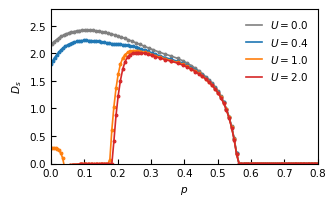

In [5]:
from pathlib import Path
import os

import matplotlib.pyplot as plt
import numpy as np


# -------------------------- paths --------------------------
data_dir = Path(".").resolve()
os.chdir(data_dir)

style_path = data_dir / "publication.mplstyle"
if style_path.exists():
    plt.style.use(style_path)


# -------------------------- normal-state density --------------------------
t = 1.0
t1 = -0.2
t2 = 0.1
Q = [np.pi, np.pi]


def band(kx, ky):
    return (
        -2.0 * t * (np.cos(kx) + np.cos(ky))
        - 4.0 * t1 * np.cos(kx) * np.cos(ky)
        - 2.0 * t2 * (np.cos(2.0 * kx) + np.cos(2.0 * ky))
    )


def band_Q(kx, ky):
    return (
        -2.0 * t * (np.cos(kx + Q[0]) + np.cos(ky + Q[1]))
        - 4.0 * t1 * np.cos(kx + Q[0]) * np.cos(ky + Q[1])
        - 2.0 * t2 * (
            np.cos(2.0 * (kx + Q[0])) + np.cos(2.0 * (ky + Q[1]))
        )
    )


def occupation_Q_per_spin(epsilon, epsilon_Q, mu, U, T):
    epsilon_minus_mu = epsilon - mu
    epsilon_Q_minus_mu = epsilon_Q - mu

    if T < 1e-8:
        T = 1e-8

    beta_T = 1.0 / T

    E_0 = np.zeros_like(epsilon_minus_mu)
    E_1 = -beta_T * epsilon_Q_minus_mu
    E_2 = -beta_T * (epsilon_minus_mu + epsilon_Q_minus_mu + U)
    E_3 = -beta_T * epsilon_minus_mu

    E_max = np.maximum.reduce([E_0, E_1, E_2, E_3])

    numerator = np.exp(E_1 - E_max) + np.exp(E_2 - E_max)
    denominator = (
        np.exp(E_0 - E_max)
        + np.exp(E_1 - E_max)
        + np.exp(E_2 - E_max)
        + np.exp(E_3 - E_max)
    )

    return numerator / denominator


def average_occupation_normal(mu, T, U, KX, KY, N):
    epsilon = band(KX, KY)
    epsilon_Q = band_Q(KX, KY)
    n_k = occupation_Q_per_spin(epsilon, epsilon_Q, mu, U, T)

    return 2.0 * np.sum(n_k) / N


def normal_doping_values(mu_values, T, U, KX, KY, N):
    doping = []

    for mu in mu_values:
        filling = average_occupation_normal(mu, T, U, KX, KY, N)
        doping.append(1.0 - filling)

    return np.array(doping)


def normal_doping_filename(data_dir, Nk_density, U, beta):
    return data_dir / f"normal_doping_Nk{Nk_density}_U={U}_beta={beta}.npy"


def load_or_compute_normal_doping(data_dir, mu_values, T, U, beta, KX, KY, N, Nk_density):
    path = normal_doping_filename(data_dir, Nk_density, U, beta)

    if path.exists():
        doping_normal = np.load(path)

        if len(doping_normal) != len(mu_values):
            raise ValueError(
                f"Saved normal doping length mismatch for U={U}: "
                f"len(doping_normal)={len(doping_normal)}, "
                f"len(mu_values)={len(mu_values)}. "
                "Delete the saved file or recompute with the same mu_values."
            )

        return doping_normal

    doping_normal = normal_doping_values(mu_values, T, U, KX, KY, N)
    np.save(path, doping_normal)

    return doping_normal


# -------------------------- saved stiffness --------------------------
def load_stiffness(data_dir, nk_delta, nk_stiffness, U, J, beta):
    tag = f"nkdelta{nk_delta}_nkstiff{nk_stiffness}_U={U}_J={J}_beta={beta}"
    stiffness_path = data_dir / f"stiffness_{tag}.npy"

    return np.load(stiffness_path)


# -------------------------- user parameters --------------------------
nk_delta = 128
nk_stiffness = 256
beta = 100
J = 0.8
U_values = [0.0, 0.4, 1.0, 2.0]

mu_values = np.linspace(-2.5, 0.0, 121)

T = 1.0 / beta

Nk_density = 512
kx_list = np.linspace(-np.pi, np.pi, Nk_density, endpoint=False)
ky_list = np.linspace(-np.pi, np.pi, Nk_density, endpoint=False)
KX, KY = np.meshgrid(kx_list, ky_list)
N = Nk_density * Nk_density

xlim = (0.0, 0.8)
ylim = (0.0, 2.8)


# -------------------------- plot --------------------------
fig, ax = plt.subplots()

colors = ["gray", "C0", "C1", "C3"]
# colors = [ "C0", "C1", "C2", "C3"]
# markers = ["o", "s", "^", "D"]
markers = ["o", "o", "o", "o"]

for U, color, marker in zip(U_values, colors, markers):
    stiffness = load_stiffness(data_dir, nk_delta, nk_stiffness, U, J, beta)

    doping_normal = load_or_compute_normal_doping(
        data_dir=data_dir,
        mu_values=mu_values,
        T=T,
        U=U,
        beta=beta,
        KX=KX,
        KY=KY,
        N=N,
        Nk_density=Nk_density,
    )

    if len(stiffness) != len(doping_normal):
        raise ValueError(
            f"Length mismatch for U={U}: "
            f"len(stiffness)={len(stiffness)}, "
            f"len(doping_normal)={len(doping_normal)}. "
            "Please make sure stiffness was computed using "
            "mu_values = np.linspace(-2.5, 0, 121)."
        )

    order = np.argsort(doping_normal)
    doping_normal = doping_normal[order]
    stiffness = stiffness[order]

    ax.plot(
        doping_normal,
        stiffness,
        "-",
        color=color,
        linewidth=1.2,
        label=rf"$U={U:.1f}$",
    )

    ax.plot(
        doping_normal,
        stiffness,
        marker,
        color=color,
        markersize=2.0,
        linestyle="None",
    )

ax.set_xlabel(r"$p$")
ax.set_ylabel(r"$D_s$")

if xlim is not None:
    ax.set_xlim(*xlim)

if ylim is not None:
    ax.set_ylim(*ylim)
else:
    ax.set_ylim(bottom=0.0)

ax.legend(loc="best", handlelength=1.5, numpoints=1, frameon=False)
ax.tick_params(direction="in")

fig.tight_layout()

# plt.savefig("fermi_arc_stiffness.pdf", bbox_inches="tight")
plt.savefig("fermi_arc_stiffness.png", dpi=600, bbox_inches="tight")
# plt.close()
plt.show()

C:\Users\fishb\AppData\Local\Temp\ipykernel_19308\3389576333.py:183: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


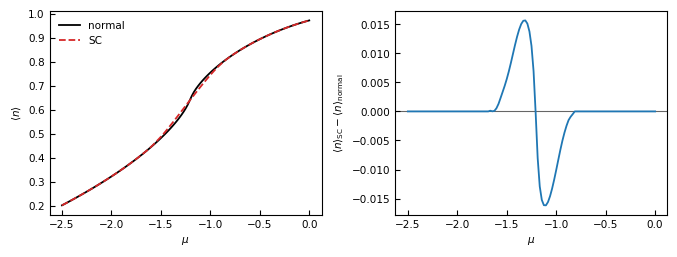

In [17]:
from pathlib import Path
import os

import matplotlib.pyplot as plt
import numpy as np


# -------------------------- paths --------------------------
data_dir = Path(".").resolve()
os.chdir(data_dir)

style_path = data_dir / "publication.mplstyle"
if style_path.exists():
    plt.style.use(style_path)


# -------------------------- normal-state density --------------------------
t = 1.0
t1 = -0.2
t2 = 0.1
Q = [np.pi, np.pi]


def band(kx, ky):
    return (
        -2.0 * t * (np.cos(kx) + np.cos(ky))
        - 4.0 * t1 * np.cos(kx) * np.cos(ky)
        - 2.0 * t2 * (np.cos(2.0 * kx) + np.cos(2.0 * ky))
    )


def band_Q(kx, ky):
    return (
        -2.0 * t * (np.cos(kx + Q[0]) + np.cos(ky + Q[1]))
        - 4.0 * t1 * np.cos(kx + Q[0]) * np.cos(ky + Q[1])
        - 2.0 * t2 * (
            np.cos(2.0 * (kx + Q[0])) + np.cos(2.0 * (ky + Q[1]))
        )
    )


def occupation_Q_per_spin(epsilon, epsilon_Q, mu, U, T):
    epsilon_minus_mu = epsilon - mu
    epsilon_Q_minus_mu = epsilon_Q - mu

    if T < 1e-8:
        T = 1e-8

    beta_T = 1.0 / T

    E_0 = np.zeros_like(epsilon_minus_mu)
    E_1 = -beta_T * epsilon_Q_minus_mu
    E_2 = -beta_T * (epsilon_minus_mu + epsilon_Q_minus_mu + U)
    E_3 = -beta_T * epsilon_minus_mu

    E_max = np.maximum.reduce([E_0, E_1, E_2, E_3])

    numerator = np.exp(E_1 - E_max) + np.exp(E_2 - E_max)
    denominator = (
        np.exp(E_0 - E_max)
        + np.exp(E_1 - E_max)
        + np.exp(E_2 - E_max)
        + np.exp(E_3 - E_max)
    )

    return numerator / denominator


def average_occupation_normal(mu, T, U, KX, KY, N):
    epsilon = band(KX, KY)
    epsilon_Q = band_Q(KX, KY)

    n_k = occupation_Q_per_spin(epsilon, epsilon_Q, mu, U, T)

    return 2.0 * np.sum(n_k) / N


def normal_filling_values(mu_values, T, U, KX, KY, N):
    filling = []

    for mu in mu_values:
        filling.append(average_occupation_normal(mu, T, U, KX, KY, N))

    return np.array(filling)


# -------------------------- saved superconducting doping --------------------------
def load_sc_doping(data_dir, nk_delta, nk_stiffness, U, J, beta):
    tag = f"nkdelta{nk_delta}_nkstiff{nk_stiffness}_U={U}_J={J}_beta={beta}"
    doping_path = data_dir / f"doping_{tag}.npy"

    return np.load(doping_path)


# -------------------------- user parameters --------------------------
nk_delta = 32
nk_stiffness = 256
beta = 100
J = 0.8
U = 2.0

mu_values = np.linspace(-2.5, 0.0, 121)
T = 1.0 / beta

Nk_density = 512
kx_list = np.linspace(-np.pi, np.pi, Nk_density, endpoint=False)
ky_list = np.linspace(-np.pi, np.pi, Nk_density, endpoint=False)
KX, KY = np.meshgrid(kx_list, ky_list)
N = Nk_density * Nk_density


# -------------------------- compute/load --------------------------
doping_sc = load_sc_doping(data_dir, nk_delta, nk_stiffness, U, J, beta)
filling_sc = 1.0 - doping_sc

filling_normal = normal_filling_values(mu_values, T, U, KX, KY, N)

if len(filling_sc) != len(mu_values):
    raise ValueError(
        f"Length mismatch: len(filling_sc)={len(filling_sc)}, "
        f"len(mu_values)={len(mu_values)}. "
        "Please make sure the saved SC doping was computed using "
        "mu_values = np.linspace(-2.5, 0, 121)."
    )

filling_diff = filling_sc - filling_normal


# -------------------------- plot --------------------------
fig, axes = plt.subplots(
    1,
    2,
    figsize=(6.8, 2.6),
)

ax = axes[0]

ax.plot(
    mu_values,
    filling_normal,
    "-",
    color="black",
    linewidth=1.3,
    label=r"normal",
)

ax.plot(
    mu_values,
    filling_sc,
    "--",
    color="C3",
    linewidth=1.3,
    label=r"SC",
)

ax.set_xlabel(r"$\mu$")
ax.set_ylabel(r"$\langle n\rangle$")
ax.legend(frameon=False)
ax.tick_params(direction="in")


ax = axes[1]

ax.axhline(
    0.0,
    color="black",
    linewidth=0.8,
    alpha=0.6,
)

ax.plot(
    mu_values,
    filling_diff,
    "-",
    color="C0",
    linewidth=1.3,
)

ax.set_xlabel(r"$\mu$")
ax.set_ylabel(r"$\langle n\rangle_{\mathrm{SC}}-\langle n\rangle_{\mathrm{normal}}$")
ax.tick_params(direction="in")

fig.tight_layout()

# plt.savefig("compare_sc_normal_filling.pdf", bbox_inches="tight")
# plt.close()
plt.show()